# 00 — Quickstart

This notebook gets you from "I just installed the SDK" to "I have a wind-speed
result over a city block" in one page.

**Time:** ~30 seconds (one analysis on a 1-tile polygon).

**Apache-2.0** — see the SDK repository for the full license.

## 1. Setup

Install dependencies (one-time) and load your API key from `.env`. See the
top-level `README.md` of `public-demos/` for setup instructions if you
haven't already.

In [1]:
from dotenv import load_dotenv
load_dotenv()  # loads INFRARED_API_KEY from .env in this directory

from infrared_sdk import InfraredClient
from infrared_sdk.analyses.types import AnalysesName, WindModelRequest
from cities import get

city = get("munich")  # try: "munich", "new_york", "sao_paulo", "tokyo", "sydney"
print(f"Running over: {city.name}, {city.country}  ({city.latitude}, {city.longitude})")

Running over: Munich, Germany  (48.1374, 11.5755)


## 2. Fetch buildings

The Area API needs the actual 3D building geometry to run physics-based
analyses. `client.buildings.get_area(polygon)` returns an `AreaBuildings`
with `buildings` (a dict of `DotBimMesh`) and `total_buildings`.

In [2]:
with InfraredClient() as client:
    area = client.buildings.get_area(city.polygon_small)
    print(f"Found {area.total_buildings} buildings.")

Found 340 buildings.


## 3. Run a wind-speed analysis

`run_area_and_wait` submits one or more analyses, tiles the polygon,
runs them in parallel, and blocks until done. It returns a list of
`AreaResult` objects (one per payload).

In [3]:
with InfraredClient() as client:
    [result] = client.run_area_and_wait(
        [WindModelRequest(
            analysis_type=AnalysesName.wind_speed,
            wind_speed=5,
            wind_direction=270,  # west wind, in degrees
        )],
        city.polygon_small,
        buildings=area.buildings,
    )

import numpy as np
valid = result.merged_grid[~np.isnan(result.merged_grid)]
print(f"grid shape   : {result.grid_shape}")
print(f"jobs         : {result.succeeded_jobs}/{result.total_jobs}")
print(f"value range  : [{float(valid.min()):.2f}, {float(valid.max()):.2f}] m/s")

grid shape   : (256, 256)
jobs         : 1/1
value range  : [0.44, 6.34] m/s


## 4. Visualise

`result.merged_grid` is a NumPy array (with `NaN` outside the polygon).
Plot it with matplotlib, or POST it through the SDK's `gen_grid_image`
to get a PNG with the canonical Infrared colormap.

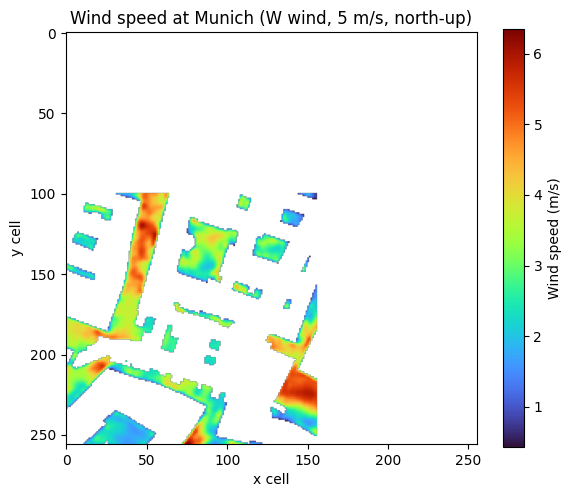

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# SDK convention: row 0 = south. Matplotlib's imshow places row 0 at the top
# of the image, so flip vertically for north-up.
plt.figure(figsize=(6, 5))
plt.imshow(np.flipud(result.merged_grid), cmap="turbo",
           vmin=result.min_legend, vmax=result.max_legend)
plt.colorbar(label="Wind speed (m/s)")
plt.title(f"Wind speed at {city.name} (W wind, 5 m/s, north-up)")
plt.xlabel("x cell"); plt.ylabel("y cell")
plt.tight_layout()
plt.show()

## What's next

| Topic                         | Notebook                            |
| ----------------------------- | ----------------------------------- |
| Building geometry in detail   | `01_buildings.ipynb`                |
| Vegetation and ground layers  | `02_vegetation_and_ground.ipynb`    |
| Weather data and time periods | `03_weather_and_time_periods.ipynb` |
| How tiling works              | `04_tiling_and_area_api.ipynb`      |
| All 8 analysis types          | `05_analysis_types_tour.ipynb`      |
| PNG rendering via the SDK     | `06_image_rendering.ipynb`          |
| Async jobs and webhooks       | `07_async_and_webhooks.ipynb`       |